In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# reading data
data = pd.read_csv('/content/drive/MyDrive/life_expectancy.csv')
data.head()

,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Corruption,Sanitation,Injuries,Communicable,NonCommunicable
0,Afghanistan,AFG,South Asia,Low income,2001,56.308,47.8,730.0,NaN,NaN,10.809000,NaN,NaN,2179727.10,9689193.70,5795426.38
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2001,47.059,67.5,15960.0,4.483516,NaN,4.004000,NaN,NaN,1392080.71,11190210.53,2663516.34
2,Albania,ALB,Europe & Central Asia,Upper middle income,2001,74.288,4.9,3230.0,7.139524,3.4587,18.575001,NaN,40.520895,117081.67,140894.78,532324.75
3,Andorra,AND,Europe & Central Asia,High income,2001,NaN,NaN,520.0,5.865939,NaN,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,United Arab Emirates,ARE,Middle East & North Africa,High income,2001,74.544,2.8,97200.0,2.484370,NaN,2.493000,NaN,NaN,144678.14,65271.91,481740.70


In [5]:
data_drop_corruption = data.copy()
data_drop_corruption.head()

,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Corruption,Sanitation,Injuries,Communicable,NonCommunicable
0,Afghanistan,AFG,South Asia,Low income,2001,56.308,47.8,730.0,NaN,NaN,10.809000,NaN,NaN,2179727.10,9689193.70,5795426.38
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2001,47.059,67.5,15960.0,4.483516,NaN,4.004000,NaN,NaN,1392080.71,11190210.53,2663516.34
2,Albania,ALB,Europe & Central Asia,Upper middle income,2001,74.288,4.9,3230.0,7.139524,3.4587,18.575001,NaN,40.520895,117081.67,140894.78,532324.75
3,Andorra,AND,Europe & Central Asia,High income,2001,NaN,NaN,520.0,5.865939,NaN,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,United Arab Emirates,ARE,Middle East & North Africa,High income,2001,74.544,2.8,97200.0,2.484370,NaN,2.493000,NaN,NaN,144678.14,65271.91,481740.70


In [6]:
data_drop = data_drop_corruption.drop(columns = 'Corruption')

In [7]:
data_merge_life_expect = data_drop.iloc[:, [2, 4, 5]]
data_merge_life_expect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Region                      3306 non-null   object 
 1   Year                        3306 non-null   int64  
 2   Life Expectancy World Bank  3118 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [8]:
target_data_nan_life_expect = data_drop.groupby(['Region', 'Year']) ['Life Expectancy World Bank'].transform(lambda x: x.fillna(x.mean()))

In [9]:
target_data_nan_life_expect.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Life Expectancy World Bank
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [10]:
data_merge_prevalence_of_under = data_drop.iloc[:, [2, 4, 6]]
data_merge_prevalence_of_under.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Region                          3306 non-null   object 
 1   Year                            3306 non-null   int64  
 2   Prevelance of Undernourishment  2622 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [11]:
target_data_nan_prevalence_of_under = data_drop.groupby(['Region', 'Year']) ['Prevelance of Undernourishment'].transform(lambda x: x.fillna(x.mean()))

In [12]:
target_data_nan_prevalence_of_under.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Prevelance of Undernourishment
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [13]:
data_merge_health_expenditure = data_drop.iloc[:, [2, 4, 8]]
data_merge_health_expenditure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                3306 non-null   object 
 1   Year                  3306 non-null   int64  
 2   Health Expenditure %  3126 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [14]:
target_data_nan_health_expenditure = data_drop.groupby(['Region', 'Year']) ['Health Expenditure %'].transform(lambda x: x.fillna(x.mean()))

In [15]:
target_data_nan_health_expenditure.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Health Expenditure %
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [16]:
data_merge_education_expenditure = data_drop.iloc[:, [2, 4, 9]]
# 1090 nan, contemplating whether filling this nan is even worth it.
data_merge_education_expenditure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Region                   3306 non-null   object 
 1   Year                     3306 non-null   int64  
 2   Education Expenditure %  2216 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [17]:
target_data_nan_education_expenditure = data_drop.groupby(['Region', 'Year']) ['Education Expenditure %'].transform(lambda x: x.fillna(x.mean()))

In [18]:
target_data_nan_education_expenditure.info()
data_drop['Education Expenditure %'].isna().sum()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Education Expenditure %
Non-Null Count  Dtype  
--------------  -----  
3294 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


np.int64(1090)

In [19]:
# Forward fill ffill()
data_drop['Education Expenditure %'] = data_drop.groupby('Region')['Education Expenditure %'].transform(lambda x: x.sort_values().ffill())

# Backward fill bfill()
data_drop['Education Expenditure %'] = data_drop.groupby('Region')['Education Expenditure %'].transform(lambda x: x.sort_values().bfill())

# Backward fill
#data_drop['Education Expenditure %'].fillna(data_drop['Education Expenditure %'].mean(), inplace=True)

target_data_nan_education_expenditure_updated = data_drop['Education Expenditure %']

In [20]:
target_data_nan_education_expenditure_updated.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Education Expenditure %
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [21]:
target_data_nan_education_expenditure.isna().any()

np.True_

In [22]:
target_data_nan_education_expenditure_updated.isna().any()

np.False_

In [23]:
data_merge_unemployment = data_drop.iloc[:, [2, 4, 10]]
# similar to the previous column, 1247 nan. Thinking if i should fill this nan
data_merge_unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Region        3306 non-null   object 
 1   Year          3306 non-null   int64  
 2   Unemployment  3002 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [24]:
target_data_nan_unemployment = data_drop.groupby(['Region', 'Year']) ['Unemployment'].transform(lambda x: x.fillna(x.mean()))

In [25]:
target_data_nan_unemployment.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Unemployment
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [26]:
data_merge_sanitation = data_drop.iloc[:, [2, 4, 11]]
# similar to the previous column, 1247 nan. Thinking if i should fill this nan
data_merge_sanitation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Region      3306 non-null   object 
 1   Year        3306 non-null   int64  
 2   Sanitation  2059 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 77.6+ KB


In [27]:
target_data_nan_sanitation = data_drop.groupby(['Region', 'Year']) ['Sanitation'].transform(lambda x: x.fillna(x.mean()))

In [28]:
target_data_nan_sanitation.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Sanitation
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [29]:
data_merge_CO2 = data_drop.iloc[:, [2, 4, 7]]
data_merge_CO2.isna().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Region  3306 non-null   bool 
 1   Year    3306 non-null   bool 
 2   CO2     3306 non-null   bool 
dtypes: bool(3)
memory usage: 9.8 KB


In [30]:
target_data_nan_CO2 = data_drop.groupby(['Region', 'Year']) ['CO2'].transform(lambda x: x.fillna(x.mean()))

In [31]:
target_data_nan_CO2.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: CO2
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [32]:
data_drop['CO2'] = target_data_nan_CO2
data_drop['Education Expenditure %'] = target_data_nan_education_expenditure_updated
data_drop['Health Expenditure %'] = target_data_nan_health_expenditure
data_drop['Prevelance of Undernourishment'] = target_data_nan_prevalence_of_under
data_drop['Unemployment'] = target_data_nan_unemployment
data_drop['Life Expectancy World Bank'] = target_data_nan_life_expect
data_drop['Sanitation'] = target_data_nan_sanitation

In [33]:
data_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    3306 non-null   object 
 1   Country Code                    3306 non-null   object 
 2   Region                          3306 non-null   object 
 3   IncomeGroup                     3306 non-null   object 
 4   Year                            3306 non-null   int64  
 5   Life Expectancy World Bank      3306 non-null   float64
 6   Prevelance of Undernourishment  3306 non-null   float64
 7   CO2                             3306 non-null   float64
 8   Health Expenditure %            3306 non-null   float64
 9   Education Expenditure %         3306 non-null   float64
 10  Unemployment                    3306 non-null   float64
 11  Sanitation                      3306 non-null   float64
 12  Injuries                        33

In [34]:
data_drop_copy = data_drop.copy()
data_drop_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    3306 non-null   object 
 1   Country Code                    3306 non-null   object 
 2   Region                          3306 non-null   object 
 3   IncomeGroup                     3306 non-null   object 
 4   Year                            3306 non-null   int64  
 5   Life Expectancy World Bank      3306 non-null   float64
 6   Prevelance of Undernourishment  3306 non-null   float64
 7   CO2                             3306 non-null   float64
 8   Health Expenditure %            3306 non-null   float64
 9   Education Expenditure %         3306 non-null   float64
 10  Unemployment                    3306 non-null   float64
 11  Sanitation                      3306 non-null   float64
 12  Injuries                        33

# Predictive Modelling

In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [36]:
longevity_data_predict = data_drop.drop(columns=['Life Expectancy World Bank'])
y = data_drop['Life Expectancy World Bank']

In [37]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3306 entries, 0 to 3305
Series name: Life Expectancy World Bank
Non-Null Count  Dtype  
--------------  -----  
3306 non-null   float64
dtypes: float64(1)
memory usage: 26.0 KB


In [38]:
longevity_data_predict.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    3306 non-null   object 
 1   Country Code                    3306 non-null   object 
 2   Region                          3306 non-null   object 
 3   IncomeGroup                     3306 non-null   object 
 4   Year                            3306 non-null   int64  
 5   Prevelance of Undernourishment  3306 non-null   float64
 6   CO2                             3306 non-null   float64
 7   Health Expenditure %            3306 non-null   float64
 8   Education Expenditure %         3306 non-null   float64
 9   Unemployment                    3306 non-null   float64
 10  Sanitation                      3306 non-null   float64
 11  Injuries                        3306 non-null   float64
 12  Communicable                    33

In [39]:
longevity_data_predict.isna().any()

,0
Country Name,False
Country Code,False
Region,False
IncomeGroup,False
Year,False
Prevelance of Undernourishment,False
CO2,False
Health Expenditure %,False
Education Expenditure %,False
Unemployment,False


In [40]:
longevity_data_num = longevity_data_predict.select_dtypes(exclude=object)
longevity_data_cat = longevity_data_predict.select_dtypes(include=object)

In [41]:
longevity_data_num

,Year,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Sanitation,Injuries,Communicable,NonCommunicable
0,2001,47.800000,730.000000,4.321165,7.59010,10.809000,25.078307,2179727.10,9689193.70,5795426.38
1,2001,67.500000,15960.000000,4.483516,13.21957,4.004000,11.166260,1392080.71,11190210.53,2663516.34
2,2001,4.900000,3230.000000,7.139524,3.45870,18.575001,40.520895,117081.67,140894.78,532324.75
3,2001,4.814634,520.000000,5.865939,12.00460,10.404860,21.788660,1697.99,695.56,13636.64
4,2001,2.800000,97200.000000,2.484370,9.26467,2.493000,51.930795,144678.14,65271.91,481740.70
...,...,...,...,...,...,...,...,...,...,...
3301,2019,12.400000,209.999993,3.360347,1.77788,1.801000,59.353110,12484.18,26032.56,69213.56
3302,2019,4.400000,300.000012,6.363094,4.70625,8.406000,47.698788,6652.84,9095.19,43798.62
3303,2019,6.300000,439640.014648,9.109355,5.91771,28.469999,20.148443,3174676.10,13198944.71,10214261.89
3304,2019,20.450000,6800.000191,5.312203,4.46518,12.520000,20.148443,510982.75,4837094.00,2649687.82


In [42]:
longevity_data_num.columns

Index(['Year', 'Prevelance of Undernourishment', 'CO2', 'Health Expenditure %',
       'Education Expenditure %', 'Unemployment', 'Sanitation', 'Injuries',
       'Communicable', 'NonCommunicable'],
      dtype='object')

In [43]:
longevity_data_cat

,Country Name,Country Code,Region,IncomeGroup
0,Afghanistan,AFG,South Asia,Low income
1,Angola,AGO,Sub-Saharan Africa,Lower middle income
2,Albania,ALB,Europe & Central Asia,Upper middle income
3,Andorra,AND,Europe & Central Asia,High income
4,United Arab Emirates,ARE,Middle East & North Africa,High income
...,...,...,...,...
3301,Vanuatu,VUT,East Asia & Pacific,Lower middle income
3302,Samoa,WSM,East Asia & Pacific,Lower middle income
3303,South Africa,ZAF,Sub-Saharan Africa,Upper middle income
3304,Zambia,ZMB,Sub-Saharan Africa,Low income


In [44]:
longevity_data_cat.columns

Index(['Country Name', 'Country Code', 'Region', 'IncomeGroup'], dtype='object')

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(longevity_data_num)

longevity_scaled_data = pd.DataFrame(longevity_data_predict, columns=longevity_data_num.columns)
display(longevity_scaled_data.describe().T)
display(longevity_scaled_data.corr())

,count,mean,std,min,25%,50%,75%,max
Year,3306.0,2.010000e+03,5.478054e+00,2001.000000,2005.000000,2.010000e+03,2.015000e+03,2.019000e+03
Prevelance of Undernourishment,3306.0,1.105566e+01,1.062263e+01,2.500000,2.600000,7.400000e+00,1.620000e+01,7.090000e+01
CO2,3306.0,1.767375e+05,7.843258e+05,10.000000,2182.500064,1.208000e+04,7.136000e+04,1.070722e+07
Health Expenditure %,3306.0,6.398471e+00,2.813426e+00,1.263576,4.304727,5.987030e+00,8.051912e+00,2.423068e+01
Education Expenditure %,3306.0,7.724252e+00,5.542061e+00,0.850320,3.698569,5.431240e+00,1.200460e+01,2.327000e+01
Unemployment,3306.0,7.751613e+00,6.046512e+00,0.100000,3.730250,5.956000e+00,9.873250e+00,3.725000e+01
Sanitation,3306.0,4.633902e+01,2.784735e+01,2.377647,19.647712,4.214932e+01,6.965940e+01,1.000000e+02
Injuries,3306.0,1.318219e+06,5.214068e+06,430.490000,62456.877500,2.456910e+05,8.465591e+05,5.563676e+07
Communicable,3306.0,4.686289e+06,1.843727e+07,330.160000,57764.745000,3.147693e+05,2.831636e+06,2.685646e+08
NonCommunicable,3306.0,7.392488e+06,2.932688e+07,2481.820000,318475.837500,1.350146e+06,3.918468e+06,3.246378e+08


,Year,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Sanitation,Injuries,Communicable,NonCommunicable
Year,1.000000,-0.158658,0.022931,0.095742,-0.142393,-0.052354,0.122392,-0.005951,-0.037286,0.018347
Prevelance of Undernourishment,-0.158658,1.000000,-0.134534,-0.225205,0.086310,-0.051497,-0.560493,0.007319,0.141010,-0.043661
CO2,0.022931,-0.134534,1.000000,0.150118,-0.051099,-0.059839,0.150494,0.617354,0.192460,0.781801
Health Expenditure %,0.095742,-0.225205,0.150118,1.000000,0.117684,0.103084,0.257368,-0.088396,-0.175460,-0.047899
Education Expenditure %,-0.142393,0.086310,-0.051099,0.117684,1.000000,0.007489,-0.053812,-0.060626,-0.049541,-0.066523
Unemployment,-0.052354,-0.051497,-0.059839,0.103084,0.007489,1.000000,-0.103079,-0.067374,-0.090563,-0.078735
Sanitation,0.122392,-0.560493,0.150494,0.257368,-0.053812,-0.103079,1.000000,-0.063428,-0.188065,-0.003699
Injuries,-0.005951,0.007319,0.617354,-0.088396,-0.060626,-0.067374,-0.063428,1.000000,0.773388,0.952623
Communicable,-0.037286,0.141010,0.192460,-0.175460,-0.049541,-0.090563,-0.188065,0.773388,1.000000,0.619248
NonCommunicable,0.018347,-0.043661,0.781801,-0.047899,-0.066523,-0.078735,-0.003699,0.952623,0.619248,1.000000


In [47]:
longevity_data_catg_dum = pd.DataFrame()
for c in longevity_data_cat.columns:
    dummy = pd.get_dummies(longevity_data_cat[c], prefix=c, dtype=int)
    dummy_sum = dummy.sum(axis=0)
    col_to_drop = dummy_sum.idxmax()
    dummy = dummy.drop(columns=[col_to_drop])
    longevity_data_catg_dum = pd.concat([longevity_data_catg_dum, dummy], axis=1)

longevity_data_catg_dum

,Country Name_Albania,Country Name_Algeria,Country Name_American Samoa,Country Name_Andorra,Country Name_Angola,Country Name_Antigua and Barbuda,Country Name_Argentina,Country Name_Armenia,Country Name_Australia,Country Name_Austria,...,Country Code_ZWE,Region_East Asia & Pacific,Region_Latin America & Caribbean,Region_Middle East & North Africa,Region_North America,Region_South Asia,Region_Sub-Saharan Africa,IncomeGroup_Low income,IncomeGroup_Lower middle income,IncomeGroup_Upper middle income
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3301,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
3302,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
3303,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3304,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0


In [48]:
longevity_data_catg_dum.columns

Index(['Country Name_Albania', 'Country Name_Algeria',
       'Country Name_American Samoa', 'Country Name_Andorra',
       'Country Name_Angola', 'Country Name_Antigua and Barbuda',
       'Country Name_Argentina', 'Country Name_Armenia',
       'Country Name_Australia', 'Country Name_Austria',
       ...
       'Country Code_ZWE', 'Region_East Asia & Pacific',
       'Region_Latin America & Caribbean', 'Region_Middle East & North Africa',
       'Region_North America', 'Region_South Asia',
       'Region_Sub-Saharan Africa', 'IncomeGroup_Low income',
       'IncomeGroup_Lower middle income', 'IncomeGroup_Upper middle income'],
      dtype='object', length=355)

In [49]:
longevity_data_catg_dum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Columns: 355 entries, Country Name_Albania to IncomeGroup_Upper middle income
dtypes: int64(355)
memory usage: 9.0 MB


In [50]:
longevity_prediction = pd.concat([longevity_scaled_data, longevity_data_catg_dum], axis=1)

In [51]:
! pip install xgboost

In [52]:
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=1, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=100, weights='uniform'),
    DecisionTreeRegressor(max_depth=2),
    DecisionTreeRegressor(max_depth=5),
    DecisionTreeRegressor(max_depth=10),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=100, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    xgb.XGBRegressor(max_depth=2, learning_rate=0.1, n_estimators=100, min_child_weight=5),
]

In [53]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True)

longevity_prediction.columns = longevity_prediction.columns.astype(str) # Convert column names to strings

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, longevity_prediction, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.013719,0.000354,0.01328,0.013541,0.013703,0.013838,0.014233



KNeighborsRegressor(n_neighbors=1)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.008425,0.000383,0.007975,0.008092,0.008539,0.008624,0.008896



KNeighborsRegressor(n_neighbors=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.015336,0.000727,0.014525,0.014849,0.015244,0.01568,0.01638



GradientBoostingRegressor(max_depth=2)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.03475,0.000653,0.034034,0.034111,0.035002,0.035061,0.035542



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.035315,0.001149,0.033896,0.034636,0.035108,0.03624,0.036698


In [54]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

    "XGBoost": (
        xgb.XGBRegressor(),
        {
            "n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_child_weight': [1, 2, 5],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

longevity_prediction.columns = longevity_prediction.columns.astype(str)

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(longevity_prediction, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})


results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...
Performing GridSearchCV for XGBoost...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.008555455800711046),
  'Best Params': {'n_neighbors': 1, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.015602649555297842),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 100}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.008479312085257179),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_samples_leaf': 1,
   'n_estimators': 200}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.0203420938141821),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.013728304432730426),
  'Best Params': {'fit_intercept': True}},
 {'Model': 'XGBoost',
  'Best Score': np.float64(-0.012304330037652786),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_child_weight

In [55]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(longevity_prediction, y)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=longevity_prediction.columns).sort_values(ascending=False)
importances = importances[:20]

features_rf = importances.index

longevity_prediction_pars = longevity_prediction[ features_rf ]
importances

,0
Region_Sub-Saharan Africa,0.617941
Prevelance of Undernourishment,0.124489
Communicable,0.059312
Year,0.041327
Health Expenditure %,0.026710
Sanitation,0.020962
IncomeGroup_Lower middle income,0.013522
NonCommunicable,0.012608
CO2,0.012282
Unemployment,0.011821


In [56]:
! pip install statsmodels

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

longevity_prediction_pars_with_const = sm.add_constant(longevity_prediction_pars)

vif = pd.Series(
    [variance_inflation_factor(longevity_prediction_pars_with_const.values, i) for i in range(longevity_prediction_pars_with_const.shape[1])],
    index=longevity_prediction_pars_with_const.columns
).sort_values(ascending=False)

vif[:20]

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,0
Country Code_TKM,inf
Country Name_Turkmenistan,inf
Country Code_SWZ,inf
Country Name_Eswatini,inf
const,1.484626e+05
NonCommunicable,3.767816e+01
Injuries,3.538982e+01
CO2,5.409595e+00
Communicable,4.774713e+00
Region_Sub-Saharan Africa,3.340634e+00


In [58]:
longevity_prediction_vif = longevity_prediction_pars.copy()
while True:
  longevity_prediction_vif_with_const = sm.add_constant(longevity_prediction_vif)

  # Compute VIF for all features
  vif_series = pd.Series(
  [variance_inflation_factor(longevity_prediction_vif_with_const.values, i) for i in range(longevity_prediction_vif_with_const.shape[1])],
  index=longevity_prediction_vif_with_const.columns
    )
  #Exclude constant term
  vif_series = vif_series.drop('const', errors='ignore')
  highest_vif_feature = vif_series.idxmax()
  # Break the loop if all features have VIF ≤ 10
  if vif_series.loc[highest_vif_feature] <= 6:  # Checking the first feature after 'const'
    break

  # Drop the feature with the highest VIF
  longevity_prediction_vif = longevity_prediction_vif.drop(columns=[highest_vif_feature])

  print(f"Dropped: {highest_vif_feature} (VIF={vif_series.loc[highest_vif_feature]:.2f})")
  # end


vif_series[:25]

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropped: Country Name_Turkmenistan (VIF=inf)
Dropped: Country Name_Eswatini (VIF=inf)
Dropped: NonCommunicable (VIF=37.68)
Dropped: Injuries (VIF=6.58)


,0
Region_Sub-Saharan Africa,3.111403
Prevelance of Undernourishment,1.842160
Communicable,1.195477
Year,1.093924
Health Expenditure %,1.309959
Sanitation,3.142680
IncomeGroup_Lower middle income,1.565285
CO2,1.132919
Unemployment,1.199258
IncomeGroup_Upper middle income,1.856175


In [59]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

      "XGBoost": (
        xgb.XGBRegressor(),
        {
            "n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_child_weight': [1, 2, 5],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

longevity_prediction.columns = longevity_prediction.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(longevity_prediction_vif, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...
Performing GridSearchCV for XGBoost...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.045224641830119976),
  'Best Params': {'n_neighbors': 5, 'weights': 'distance'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.016115088457862633),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 50}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.011106925343745135),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_samples_leaf': 5,
   'n_estimators': 200}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.019472926832930525),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.04805178620106746),
  'Best Params': {'fit_intercept': True}},
 {'Model': 'XGBoost',
  'Best Score': np.float64(-0.012254975489032167),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_child_weigh

In [60]:
! pip install tensorflow --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 142.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 37.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-aiplatform 1.143.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7

In [61]:
! pip install keras --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.7 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.21.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.


In [62]:
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( longevity_prediction_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=longevity_prediction_train.shape[1]),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(256, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = longevity_prediction_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model

In [63]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( longevity_prediction_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(longevity_prediction_train.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(256, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = longevity_prediction_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.1
initial_learning_rate = 0.01

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(longevity_prediction):
    print(f"Fold {fold}/{n_splits}")
    longevity_prediction_train, longevity_prediction_test = longevity_prediction.iloc[train_index], longevity_prediction.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        longevity_prediction_train,
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model both x and y
    history = model.fit(
        longevity_prediction_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(longevity_prediction_test, y_test),
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred = model.predict(longevity_prediction_train, verbose=0)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Evaluate on test data
    y_test_pred = model.predict(longevity_prediction_test, verbose=0)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

Fold 1/5
MAE:
  Train: 70.0054
  Test:  69.7780
R^2:
  Train: -58.4627
  Test:  -55.8897

Fold 2/5
MAE:
  Train: 69.9353
  Test:  70.0581
R^2:
  Train: -58.1512
  Test:  -57.0517

Fold 3/5
MAE:
  Train: 69.8265
  Test:  70.4934
R^2:
  Train: -57.3985
  Test:  -60.3568

Fold 4/5
MAE:
  Train: 69.9701
  Test:  69.9186
R^2:
  Train: -57.3492
  Test:  -60.3583

Fold 5/5
MAE:
  Train: 70.0619
  Test:  69.5514
R^2:
  Train: -58.3039
  Test:  -56.5789



In [64]:
cross_validation_result_df = pd.DataFrame({
    'Train MAE': train_mae_list,
    'Test MAE': test_mae_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

cross_validation_result_df.describe()

,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,69.959839,69.959891,-57.933094,-58.047084
std,0.088007,0.352117,0.522554,2.149251
min,69.826503,69.551361,-58.462696,-60.358317
25%,69.935271,69.777969,-58.303908,-60.356784
50%,69.970135,69.918623,-58.151161,-57.051703
75%,70.005371,70.058130,-57.398466,-56.578918
max,70.061916,70.493370,-57.349238,-55.889699


In [65]:
from sklearn.model_selection import train_test_split

longevity_prediction_train, longevity_prediciton_test, y_train, y_test = train_test_split(longevity_prediction_vif, y,
                                                    test_size=0.2)

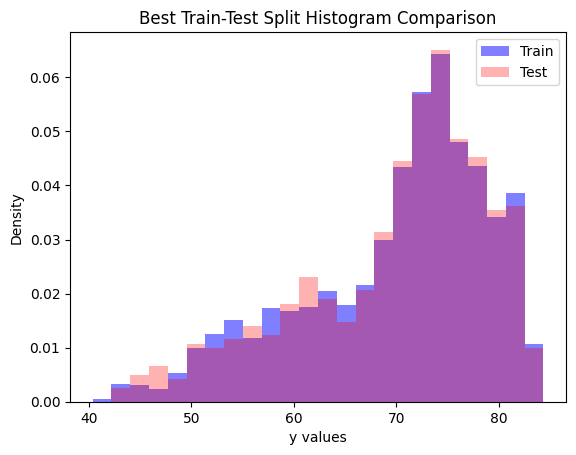

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define the number of attempts
attempts = 1000

# Determine the global min and max of y
y_min, y_max = y.min(), y.max()
bins = np.linspace(y_min, y_max, 25)  # 25 bins means 26 edges

best_mse = float('inf')
best_split = None

for i in range(attempts):
    # Perform train-test split
    longevity_prediction_train_i, longevity_prediction_test_i, y_train_i, y_test_i = train_test_split(longevity_prediction_vif, y, test_size=0.2)

    # Compute histograms
    y_train_hist, _ = np.histogram(y_train_i, bins=bins, density=True)
    y_test_hist, _ = np.histogram(y_test_i, bins=bins, density=True)

    # Compute MSE between histograms
    mse = mean_squared_error(y_train_hist, y_test_hist)

    # Save the best split
    if mse < best_mse:
        best_mse = mse
        best_split = (longevity_prediction_train_i, longevity_prediction_test_i, y_train_i, y_test_i)

# Unpack the best split
longevity_prediction_train, longevity_prediction_test, y_train, y_test = best_split

# Display histograms of the best split
plt.hist(y_train, bins=bins, alpha=0.5, color='b', label='Train', density=True)
plt.hist(y_test, bins=bins, alpha=0.3, color='r', label='Test', density=True)
plt.legend()
plt.xlabel('y values')
plt.ylabel('Density')
plt.title('Best Train-Test Split Histogram Comparison')
plt.show()

In [67]:
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

dropout_rate = 0.05 #I changed dropout rate from 0.05 to 0.01 used to prevent overfitting

# Create model complexity
model = Sequential([
    Input(shape=(longevity_prediction_train.shape[1],)),
    Dense(64, activation='relu'), # originally 32 neurons
    BatchNormalization(),
    Dropout(dropout_rate),
    Dense(128, activation='relu'), # originally 64 neurons
    BatchNormalization(),
    Dropout(dropout_rate),
    Dense(32, activation='relu'), #originally 128 neurons
    Dense(1, activation='relu'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=100,          # Stop after 5 epochs without improvement, changed from 100 to 50
    restore_best_weights=True  # Restore the best weights after stopping
)

# Display model summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [68]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500 # Originally 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = longevity_prediction_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [69]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=30,          # Stop after 50 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=30,              # number of epochs with no improvement after which LR will be reduced, changed from 50 to 40
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [70]:
# Train model
history = model.fit(
    longevity_prediction_train, y_train,
    epochs=400, #originally at 400
    batch_size=batch_size,
    shuffle=True,
    validation_data=(longevity_prediciton_test, y_test),
    verbose=1,
    callbacks=[
        early_stopping,
    ]
)

Epoch 1/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - loss: 55.9054 - val_loss: 64.7767
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26.4090 - val_loss: 20.7092
Epoch 3/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.0909 - val_loss: 13.7496
Epoch 4/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.7587 - val_loss: 21.7010
Epoch 5/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.5870 - val_loss: 16.7874
Epoch 6/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.0201 - val_loss: 15.2324
Epoch 7/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.5675 - val_loss: 12.1185
Epoch 8/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.3916 - val_loss: 10.0398
Epoch 9/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.2738 - val_loss: 9.6737
Epoch 10/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.5601 - val_loss: 9.6428
Epoch 11/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.0635 - val_loss: 10.5276
Epoch 12/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1

83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step


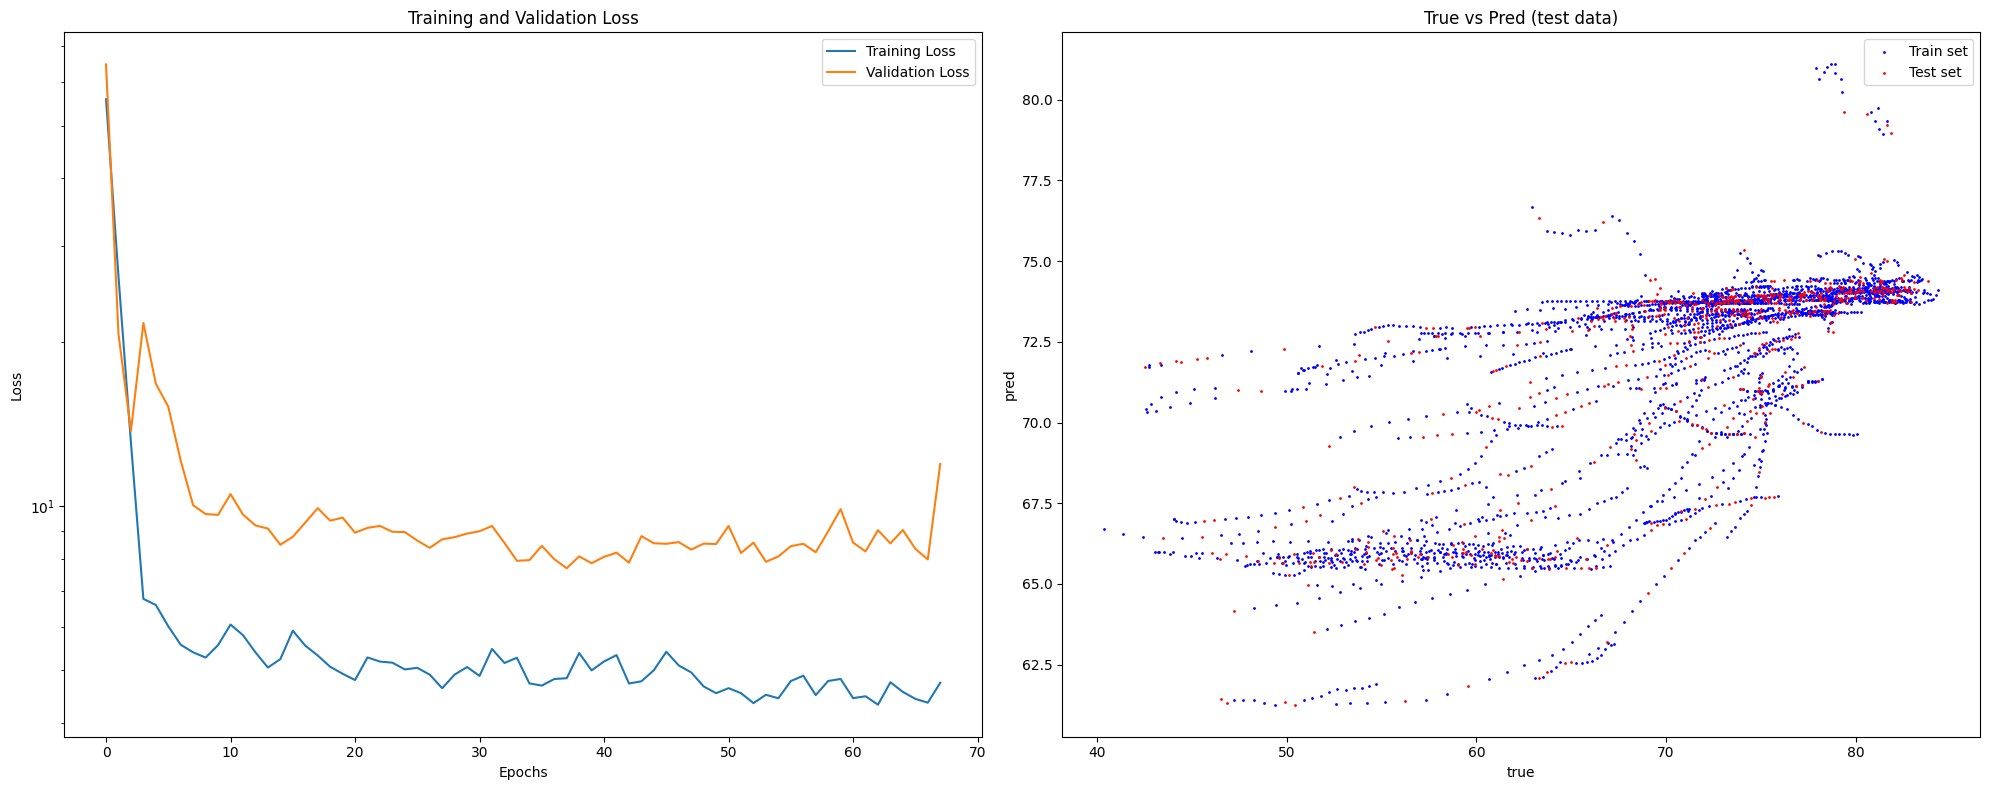

MAE:
  Train: 5.5482
  Test:  5.5609
R^2:
  Train: 0.3595
  Test:  0.3535


In [71]:
from sklearn.metrics import mean_absolute_error, r2_score

# Get predictions
y_train_pred = model.predict(longevity_prediction_train)[:,0]
y_test_pred  = model.predict(longevity_prediction_test)[:,0]

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left subplot: Training and Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_yscale('log')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right subplot: True vs Predicted Data
axes[1].scatter(y_train, y_train_pred, c='b', s=1, label="Train set")
axes[1].scatter(y_test, y_test_pred, c='r', s=1, label="Test set")
axes[1].set_title('True vs Pred (test data)')
axes[1].set_xlabel('true')
axes[1].set_ylabel('pred')
axes[1].legend()

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# Define regression models corresponding to the original classifiers
models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=5, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=50, weights='uniform'),
    RandomForestRegressor(n_estimators=100, max_leaf_nodes=3),
    RandomForestRegressor(n_estimators=100, max_leaf_nodes=10),
    RandomForestRegressor(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    DecisionTreeRegressor(max_leaf_nodes=3),
    DecisionTreeRegressor(max_leaf_nodes=10),
    xgb.XGBRegressor(max_depth=2, learning_rate=0.1, n_estimators=100, min_child_weight=5),
]

In [73]:
for m in models:
    m.fit(longevity_prediction_train, y_train)
    y_train_pred = m.predict(longevity_prediction_train)
    y_test_pred = m.predict(longevity_prediction_test)

    # Compute regression metrics
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Print model and its metrics
    print(m)
    print("MAE:")
    print(f"  Train: {mae_train:.4f}")
    print(f"  Test:  {mae_test:.4f}")
    print("R^2:")
    print(f"  Train: {r2_train:.4f}")
    print(f"  Test:  {r2_test:.4f}")
    print()
# end

LinearRegression()
MAE:
  Train: 3.1223
  Test:  3.1408
R^2:
  Train: 0.8092
  Test:  0.8100

KNeighborsRegressor()
MAE:
  Train: 2.3140
  Test:  3.1183
R^2:
  Train: 0.8379
  Test:  0.7261

KNeighborsRegressor(n_neighbors=10)
MAE:
  Train: 2.9085
  Test:  3.4517
R^2:
  Train: 0.7790
  Test:  0.6910

KNeighborsRegressor(n_neighbors=50)
MAE:
  Train: 4.1705
  Test:  4.2948
R^2:
  Train: 0.6372
  Test:  0.5988

RandomForestRegressor(max_leaf_nodes=3)
MAE:
  Train: 3.9317
  Test:  3.9526
R^2:
  Train: 0.6967
  Test:  0.6958

RandomForestRegressor(max_leaf_nodes=10)
MAE:
  Train: 2.7217
  Test:  2.8832
R^2:
  Train: 0.8579
  Test:  0.8456

RandomForestRegressor(max_leaf_nodes=30)
MAE:
  Train: 1.9248
  Test:  2.1128
R^2:
  Train: 0.9287
  Test:  0.9123

GradientBoostingRegressor(max_leaf_nodes=3)
MAE:
  Train: 2.3955
  Test:  2.5071
R^2:
  Train: 0.8908
  Test:  0.8793

GradientBoostingRegressor(max_leaf_nodes=10)
MAE:
  Train: 1.5459
  Test:  1.7734
R^2:
  Train: 0.9530
  Test:  0.9393

D

In [74]:
# Create a DataFrame to organize the data of true vs pred data graph of a R of 0.83 which is a bit low
predicted_results_df = pd.DataFrame({
    'Actual Life Expectancy': y_test,
    'Predicted Life Expectancy': y_test_pred,
    'Difference (Error)': (y_test - y_test_pred),
    'Percentage Error (%)': ((abs(y_test - y_test_pred) / y_test) * 100)
})

# Get the original 'Country Name' and 'Year' directly from data_drop using y_test's index
country_year_info = data_drop.loc[y_test.index, ['Country Name', 'Year']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df = predicted_results_df.merge(country_year_info, left_index=True, right_index=True)

# Reorder columns to have Country Name and Year at the beginning for clarity
predicted_results_df = predicted_results_df[[
    'Country Name', 'Year', 'Actual Life Expectancy', 'Predicted Life Expectancy',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Display the resulting numerical table without explicit sorting, showing the split order
predicted_results_df

,Country Name,Year,Actual Life Expectancy,Predicted Life Expectancy,Difference (Error),Percentage Error (%)
1243,Barbados,2008,78.184000,76.326416,1.857584,2.375913
1506,Niger,2009,56.557000,54.845425,1.711575,3.026284
2495,Guinea-Bissau,2015,56.959000,59.110302,-2.151302,3.776931
434,Lebanon,2003,75.969000,72.064194,3.904806,5.140000
1901,Tuvalu,2011,72.382101,72.185188,0.196913,0.272046
...,...,...,...,...,...,...
2650,Germany,2016,80.990244,81.241936,-0.251692,0.310768
3039,Kazakhstan,2018,73.150000,76.383369,-3.233369,4.420191
1568,Albania,2010,76.562000,72.433456,4.128544,5.392419
519,South Africa,2003,53.749000,55.772003,-2.023003,3.763797


In [75]:
predicted_results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 662 entries, 1243 to 3249
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country Name               662 non-null    object 
 1   Year                       662 non-null    int64  
 2   Actual Life Expectancy     662 non-null    float64
 3   Predicted Life Expectancy  662 non-null    float32
 4   Difference (Error)         662 non-null    float64
 5   Percentage Error (%)       662 non-null    float64
dtypes: float32(1), float64(3), int64(1), object(1)
memory usage: 49.8+ KB


In [76]:
# Filter predicted_results_df for 'Countries' to see all its entries in the test set
countries_predictions_corrected = predicted_results_df[predicted_results_df['Country Name'] == 'Germany'].sort_values(by='Year')
print("Country entries in the corrected predicted_results_df (from original csv dataset):")
display(countries_predictions_corrected)

# Display the specific entry for Countries in 2014 from the original data_drop
print("\nLife Expectancy for random country in 2014 from original data_drop:")
display(data_drop[(data_drop['Country Name'] == 'Germany') & (data_drop['Year'] == 2016)])

# Display all data_drop entries with Life Expectancy around 45.100
print("\nAll data_drop entries with Life Expectancy around 45.100:")
display(data_drop[data_drop['Life Expectancy World Bank'].between(45.0, 45.2)])

Country entries in the corrected predicted_results_df (from original csv dataset):


,Country Name,Year,Actual Life Expectancy,Predicted Life Expectancy,Difference (Error),Percentage Error (%)
1606,Germany,2010,79.987805,80.025635,-0.037830,0.047295
2650,Germany,2016,80.990244,81.241936,-0.251692,0.310768



Life Expectancy for random country in 2014 from original data_drop:


,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Sanitation,Injuries,Communicable,NonCommunicable
2650,Germany,DEU,Europe & Central Asia,High income,2016,80.990244,2.5,747150.024414,11.235637,4.83923,4.12,96.955427,1937140.97,975592.03,23829341.15



All data_drop entries with Life Expectancy around 45.100:


,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Sanitation,Injuries,Communicable,NonCommunicable
898,Central African Republic,CAF,Sub-Saharan Africa,Low income,2006,45.158,37.7,230.000004,4.441054,1.41506,5.659,18.691905,341076.46,3740319.70,827671.85
1656,Lesotho,LSO,Sub-Saharan Africa,Lower middle income,2010,45.100,11.6,550.000012,8.419619,13.21957,27.079,28.562729,162722.92,1216618.77,418187.33


In [77]:
# Get the original indices from y_test (which was used to create predicted_results_df)
original_indices = y_test.index

# Map these indices back to data_drop to get the 'Country Name'
country_names_for_test_set = data_drop.loc[original_indices, 'Country Name']

# Add 'Country Name' to the predicted_results_df
predicted_results_df['Country Name'] = country_names_for_test_set.values

predicted_results_df = predicted_results_df[['Country Name', 'Year','Actual Life Expectancy', 'Predicted Life Expectancy', 'Difference (Error)', 'Percentage Error (%)']]

# Display the updated DataFrame
display(predicted_results_df.head())

,Country Name,Year,Actual Life Expectancy,Predicted Life Expectancy,Difference (Error),Percentage Error (%)
1243,Barbados,2008,78.184000,76.326416,1.857584,2.375913
1506,Niger,2009,56.557000,54.845425,1.711575,3.026284
2495,Guinea-Bissau,2015,56.959000,59.110302,-2.151302,3.776931
434,Lebanon,2003,75.969000,72.064194,3.904806,5.140000
1901,Tuvalu,2011,72.382101,72.185188,0.196913,0.272046


In [78]:
! pip install shap

In [79]:
import shap

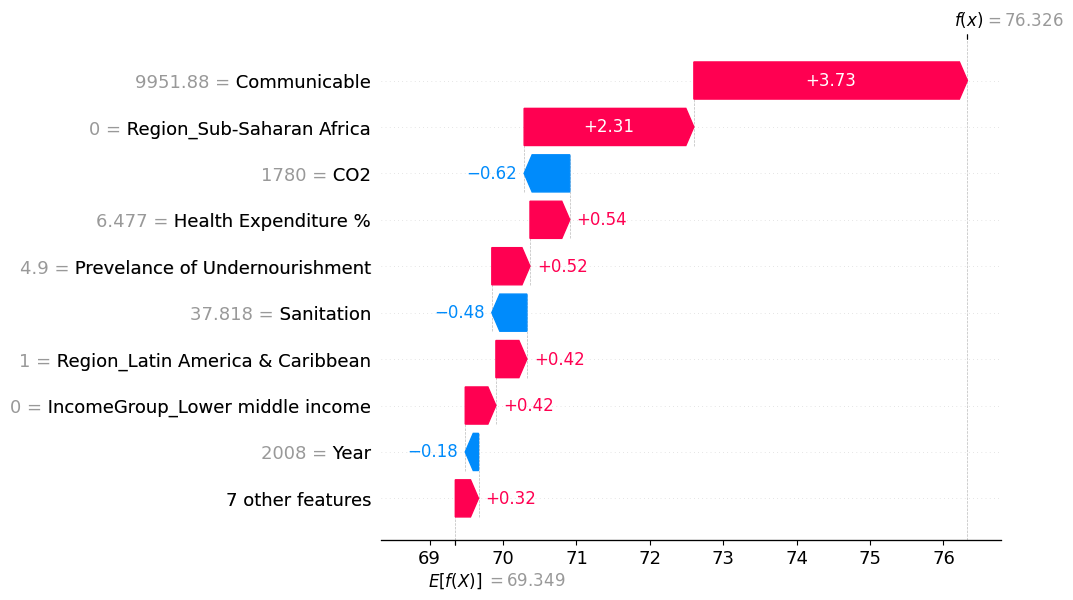

In [80]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(longevity_prediction_train, y_train)

# 2. Incorporate SHAP (No re-training needed)
import shap
explainer = shap.Explainer(m, longevity_prediction_train) # It just looks at your existing 'model'
shap_values = explainer(longevity_prediction_test)

# 3. Visualize
shap.plots.waterfall(shap_values[0])

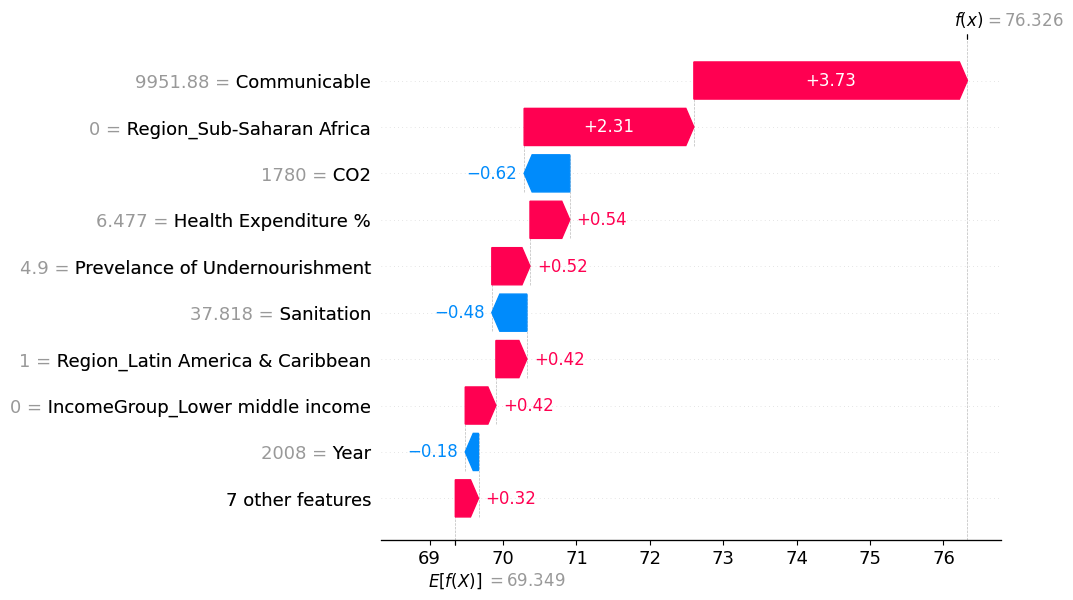

In [81]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor().fit(longevity_prediction_train, y_train)

# 2. Incorporate SHAP (No re-training needed)
import shap
explainer = shap.Explainer(m, longevity_prediction_train) # It just looks at your existing 'model'
shap_values = explainer(longevity_prediction_test)

# 3. Visualize
shap.plots.waterfall(shap_values[0])

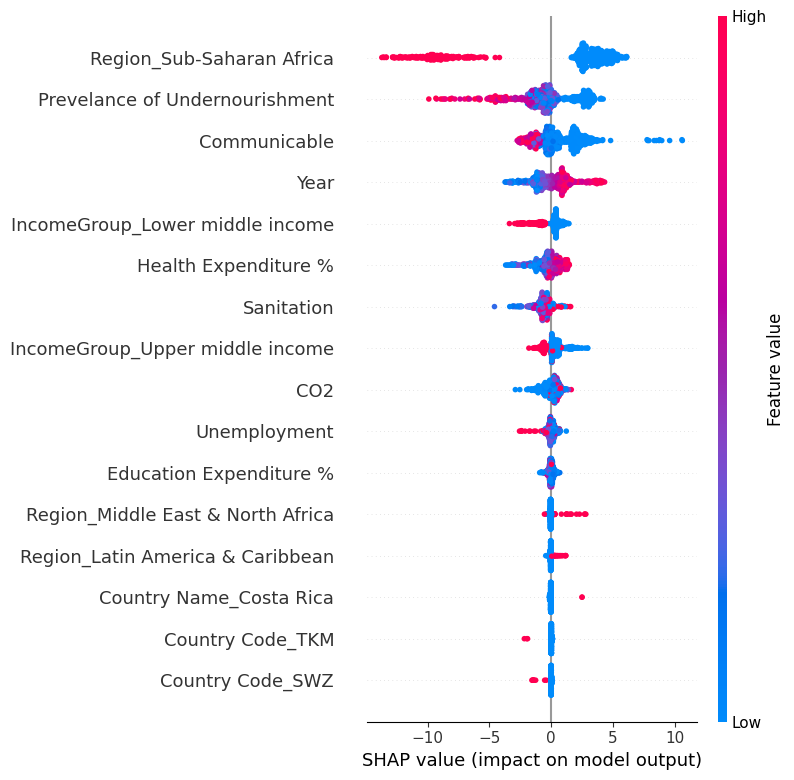

In [82]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(longevity_prediction_test)

shap.summary_plot(shap_values, longevity_prediction_test)

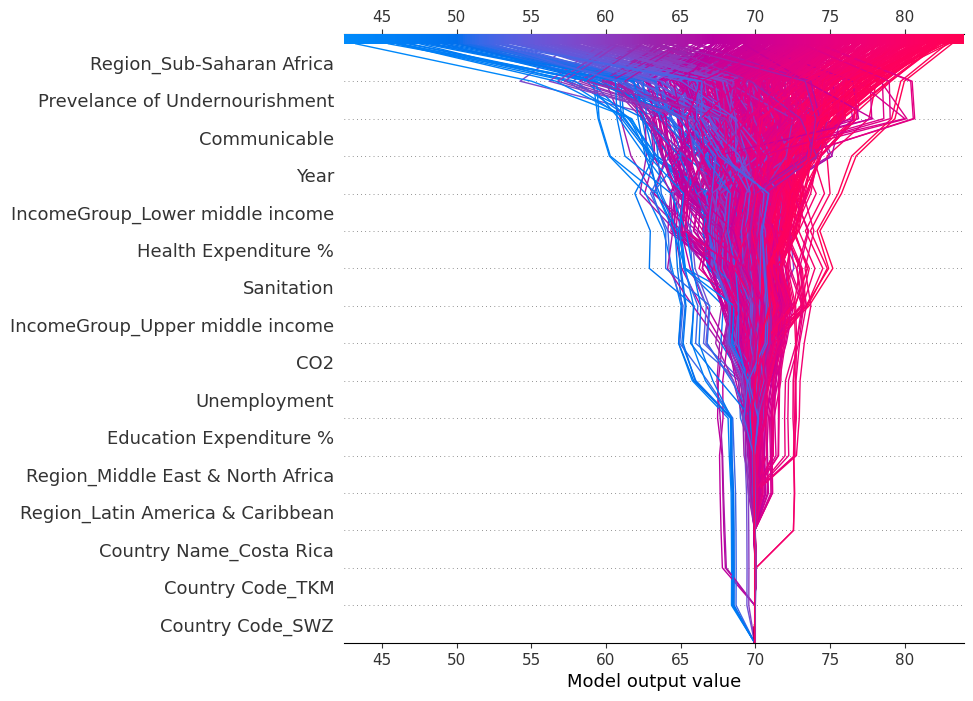

In [83]:
import shap
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(longevity_prediction_test)

shap.decision_plot(explainer.expected_value, shap_values, longevity_prediction_test)